## Asssignment 2 EDA (Section 1)

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# import pipeline
from src import config

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

raw = pd.read_csv(config.RAW_CSV)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 423,006 rows x 27 columns


,athlete_id,name,region,team,affiliate,gender,age,height,weight,fran,...,snatch,deadlift,backsq,pullups,eat,train,background,experience,schedule,howlong
0,2554.0,Pj Ablang,South West,Double Edge,Double Edge CrossFit,Male,24.0,70.0,166.0,NaN,...,NaN,400.0,305.0,NaN,NaN,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|I r...,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
1,3517.0,Derek Abdella,NaN,NaN,NaN,Male,42.0,70.0,190.0,NaN,...,NaN,NaN,NaN,NaN,NaN,I have a coach who determines my programming|I...,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affi...,I do multiple workouts in a day 2x a week|,4+ years|
2,4691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5164.0,Abo Brandon,Southern California,LAX CrossFit,LAX CrossFit,Male,40.0,67.0,NaN,211.0,...,200.0,375.0,325.0,25.0,I eat 1-3 full cheat meals per week|,I workout mostly at a CrossFit Affiliate|I hav...,I played youth or high school level sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|,4+ years|
4,5286.0,Bryce Abbey,NaN,NaN,NaN,Male,32.0,65.0,149.0,206.0,...,150.0,NaN,325.0,50.0,I eat quality foods but don't measure the amount|,I workout mostly at a CrossFit Affiliate|I inc...,I played college sports|,I began CrossFit by trying it alone (without a...,I usually only do 1 workout a day|I strictly s...,1-2 years|


### Data quality

In [3]:
key_cols = ['gender', 'age', 'height', 'weight', 'howlong', 'background', *config.LIFT_COMPONENTS]
missing = (raw[key_cols].isna().mean() * 100).round(1).sort_values(ascending=False)
missing

snatch        77.0
background    76.6
candj         75.3
howlong       74.2
backsq        73.9
deadlift      72.7
height        62.2
weight        45.7
gender        21.7
age           21.7
dtype: float64

## Cleaning

`pipeline.load_and_clean()` applies the documented rules: blank/"decline to
answer" -> NaN, plausible physical ranges (dropping extreme outliers such as
body weight > 1500 lb), non-null positive lifts, and the two main sex
categories. It also builds the `total_lift` target.

In [4]:
def load_and_clean() -> pd.DataFrame:
    """Load CSV and return a cleaned athletes DataFrame."""

    # Limit to relevant columns
    df = raw[['gender', 'age', 'height', 'weight', 'howlong', 'background', *config.LIFT_COMPONENTS]].copy()
    
    # Remove outliers
    df = df[df['weight'] < 1500]
    df = df[df['gender'] != '--']
    df = df[df['age'] >= 18]
    df = df[(df['height'] < 96) & (df['height'] > 48)]

    df = df[
        ((df['gender'] == 'Male') & (df['deadlift'] <= 1105)) |
        ((df['gender'] == 'Female') & (df['deadlift'] <= 636))
    ]
    df = df[(df['candj'] > 0) & (df['candj'] <= 395)]
    df = df[(df['snatch'] > 0) & (df['snatch'] <= 496)]
    df = df[(df['backsq'] > 0) & (df['backsq'] <= 1069)]

    # Clean survey data
    decline_dict = {'Decline to answer|': np.nan}
    df = df.replace(decline_dict)

    # Remove missing values
    df = df.dropna().copy()

    return df

In [5]:
clean = load_and_clean()
print(f"Rows: {len(raw):,} (raw) -> {len(clean):,} (clean)")
clean['total_lift'] = clean[config.LIFT_COMPONENTS].sum(axis=1)

Rows: 423,006 (raw) -> 47,061 (clean)


In [12]:
clean['howlong'].value_counts()

howlong
1-2 years|                                                                        16674
2-4 years|                                                                        14630
6-12 months|                                                                       6783
4+ years|                                                                          5052
Less than 6 months|                                                                2932
1-2 years|2-4 years|                                                                285
6-12 months|1-2 years|                                                              266
Less than 6 months|1-2 years|                                                       168
2-4 years|4+ years|                                                                  98
Less than 6 months|6-12 months|                                                      45
6-12 months|2-4 years|                                                               45
Less than 6 months|2-4 y

In [14]:
clean['background'].value_counts()

background
I played youth or high school level sports|                                                                                                                                                               17070
I played youth or high school level sports|I regularly play recreational sports|                                                                                                                           7342
I have no athletic background besides CrossFit|                                                                                                                                                            5912
I played youth or high school level sports|I played college sports|                                                                                                                                        4604
I played college sports|                                                                                                                                     

### Total Lift and feature relationships

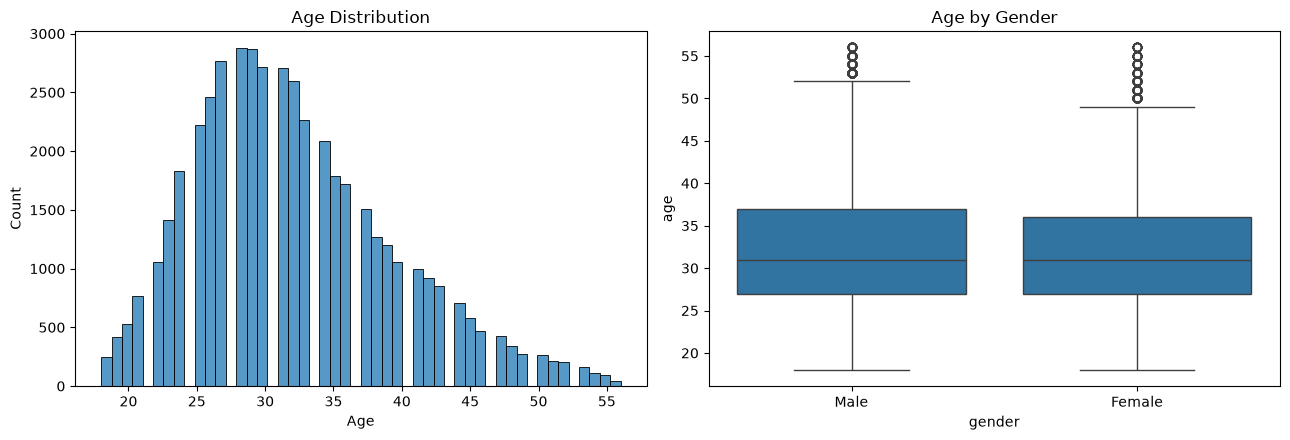

In [ ]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(clean['age'], bins=50, ax=axes[0])
axes[0].set(title="Age Distribution", xlabel="Age")
sns.boxplot(data=clean, x="gender", y='age', ax=axes[1])
axes[1].set(title="Age by Gender")
plt.tight_layout()

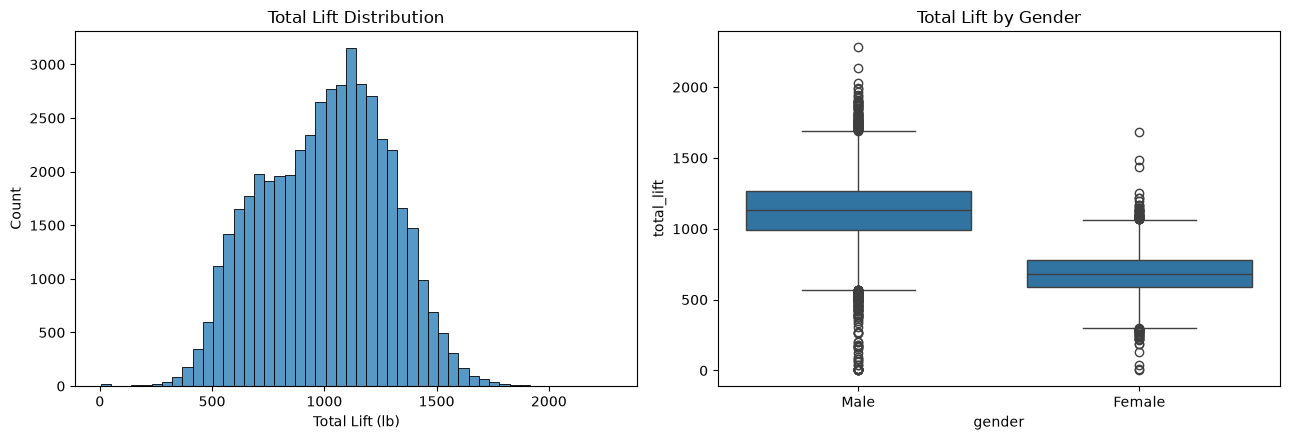

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(clean[config.TARGET], bins=50, ax=axes[0])
axes[0].set(title="Total Lift Distribution", xlabel="Total Lift (lb)")
sns.boxplot(data=clean, x="gender", y=config.TARGET, ax=axes[1])
axes[1].set(title="Total Lift by Gender")
plt.tight_layout()
plt.show()

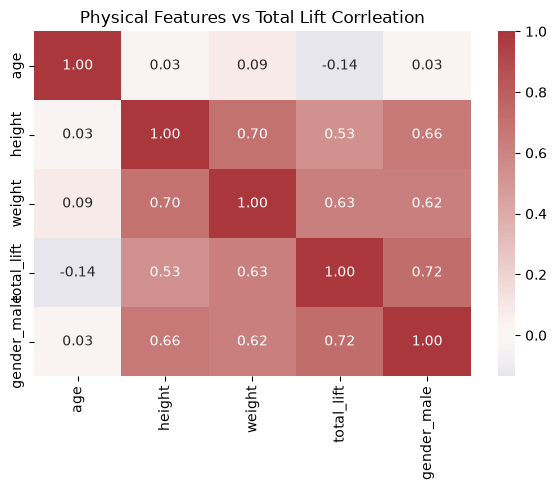

In [9]:
numeric = clean[["age", "height", "weight", config.TARGET]].copy()
numeric["gender_male"] = (clean["gender"] == "Male").astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Physical Features vs Total Lift Corrleation")
plt.tight_layout()
plt.show()